<a href="https://colab.research.google.com/github/veeresh21v-max/intelligent-voice-email-system/blob/main/Intelligent_Voice_Email_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎙️ Intelligent Voice Email System
### An NLP-powered voice assistant that composes and sends emails using your voice

**Tech Stack:** Python | SpeechRecognition | TextBlob | NLTK | SQLite | Matplotlib | yagmail

| Feature | Description |
|---|---|
| 🎤 Voice Recognition | Speaks your message, converts to text |
| 🧠 Sentiment Analysis | Detects email tone using NLP |
| 📌 Smart Subject | Auto-generates subject line |
| 🔑 Keyword Extraction | Finds key topics in your message |
| 🗄️ Email Logging | Stores history in SQLite database |
| 📊 Analytics Dashboard | Visual charts of email patterns |

*Project by: Veeresh Kambhalamatam*

In [1]:
!pip install SpeechRecognition pydub yagmail textblob nltk matplotlib pandas -q
!apt-get install ffmpeg -q
print("✅ All libraries installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 385.7/385.7 kB 17.3 MB/s eta 0:00:00
Reading package lists...
Building dependency tree...
Reading state information...
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
✅ All libraries installed!


In [2]:
import nltk
nltk.download('brown')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('stopwords')
import subprocess
subprocess.run(['python', '-m', 'textblob.download_corpora'])
print("✅ All NLTK data downloaded!")

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


✅ All NLTK data downloaded!


In [3]:
from IPython.display import Javascript, display
from google.colab import output
from base64 import b64decode
from pydub import AudioSegment
from textblob import TextBlob
from collections import Counter
import speech_recognition as sr
import sqlite3, datetime, re, io
import matplotlib.pyplot as plt
import pandas as pd
import yagmail
import nltk
import warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

print("✅ All imports successful!")

✅ All imports successful!


/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


In [4]:
def init_database():
    conn = sqlite3.connect('email_analytics.db')
    cursor = conn.cursor()
    cursor.execute('''
        CREATE TABLE IF NOT EXISTS email_logs (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            recipient TEXT, subject TEXT, message TEXT,
            sentiment_score REAL, sentiment_label TEXT,
            word_count INTEGER, timestamp TEXT, status TEXT
        )
    ''')
    conn.commit()
    conn.close()
    print("✅ Database initialized!")

init_database()

✅ Database initialized!


In [5]:
def analyze_sentiment(text):
    blob = TextBlob(text)
    polarity = blob.sentiment.polarity
    if polarity > 0.1:    label = "Positive 😊"
    elif polarity < -0.1: label = "Negative 😞"
    else:                 label = "Neutral 😐"
    return round(polarity, 3), label

def generate_smart_subject(text):
    blob = TextBlob(text)
    noun_phrases = blob.noun_phrases
    if noun_phrases:
        return f"Re: {noun_phrases[0].title()}"
    return " ".join(text.split()[:6]).title() + "..."

def extract_keywords(text, top_n=5):
    from nltk.corpus import stopwords
    stop_words = set(stopwords.words('english'))
    words = re.findall(r'\b[a-zA-Z]{3,}\b', text.lower())
    filtered = [w for w in words if w not in stop_words]
    return Counter(filtered).most_common(top_n)

def log_email(recipient, subject, message, sentiment_score, sentiment_label, status):
    conn = sqlite3.connect('email_analytics.db')
    cursor = conn.cursor()
    cursor.execute('''
        INSERT INTO email_logs
        (recipient, subject, message, sentiment_score, sentiment_label, word_count, timestamp, status)
        VALUES (?, ?, ?, ?, ?, ?, ?, ?)
    ''', (recipient, subject, message, sentiment_score, sentiment_label,
          len(message.split()),
          datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"), status))
    conn.commit()
    conn.close()

print("✅ NLP functions ready!")

✅ NLP functions ready!


In [6]:
RECORD_JS = """
const sleep = time => new Promise(resolve => setTimeout(resolve, time))
const b2text = blob => new Promise(resolve => {
  const reader = new FileReader()
  reader.onloadend = e => resolve(e.srcElement.result)
  reader.readAsDataURL(blob)
})
var record = time => new Promise(async resolve => {
  stream = await navigator.mediaDevices.getUserMedia({ audio: true })
  recorder = new MediaRecorder(stream)
  chunks = []
  recorder.ondataavailable = e => chunks.push(e.data)
  recorder.start()
  await sleep(time)
  recorder.onstop = async ()=>{
    blob = new Blob(chunks)
    text = await b2text(blob)
    resolve(text)
  }
  recorder.stop()
})
"""

def record_voice(seconds=8):
    print(f"🎤 Recording for {seconds} seconds... SPEAK NOW!")
    display(Javascript(RECORD_JS))
    audio_data = output.eval_js(f'record({seconds*1000})')
    print("⏳ Processing your voice...")

    audio_bytes = b64decode(audio_data.split(',')[1])
    audio_segment = AudioSegment.from_file(io.BytesIO(audio_bytes))
    wav_io = io.BytesIO()
    audio_segment.export(wav_io, format='wav')
    wav_io.seek(0)

    recognizer = sr.Recognizer()
    with sr.AudioFile(wav_io) as source:
        audio = recognizer.record(source)

    try:
        text = recognizer.recognize_google(audio)
        print(f"✅ You said: '{text}'")
        return text
    except sr.UnknownValueError:
        print("❌ Could not understand. Please try again!")
        return None

print("✅ Voice recorder ready!")

✅ Voice recorder ready!


In [14]:
def send_voice_email():
    print("\n" + "="*50)
    print("   🎙️ INTELLIGENT VOICE EMAIL SYSTEM")
    print("="*50)

    message = record_voice(seconds=8)
    if not message:
        return

    sentiment_score, sentiment_label = analyze_sentiment(message)
    subject = generate_smart_subject(message)
    keywords = extract_keywords(message)

    print(f"\n🧠 Sentiment  : {sentiment_label} (score: {sentiment_score})")
    print(f"🔑 Keywords   : {[kw for kw, _ in keywords]}")
    print(f"📌 Subject    : {subject}")

    print("\n" + "─"*45)
    sender_email    = input("Your Gmail        : ")
    sender_password = input("Your App Password : ")
    receiver_email  = input("Receiver Email    : ")
    print("─"*45)
    print(f"TO      : {receiver_email}")
    print(f"SUBJECT : {subject}")
    print(f"MESSAGE : {message}")
    print("─"*45)

    confirm = input("\n✅ Send? (yes/no): ").strip().lower()

    if confirm == 'yes':
        try:
            sender = yagmail.SMTP(sender_email, sender_password)
            sender.send(to=receiver_email, subject=subject, contents=message)
            print("\n🎉 Email sent successfully!")
            log_email(receiver_email, subject, message,
                     sentiment_score, sentiment_label, "sent")
        except Exception as e:
            print(f"\n❌ Failed: {e}")
            log_email(receiver_email, subject, message,
                     sentiment_score, sentiment_label, "failed")
    else:
        print("📭 Cancelled.")
        log_email(receiver_email, subject, message,
                 sentiment_score, sentiment_label, "cancelled")

send_voice_email()


   🎙️ INTELLIGENT VOICE EMAIL SYSTEM
🎤 Recording for 8 seconds... SPEAK NOW!


<IPython.core.display.Javascript object>

⏳ Processing your voice...
✅ You said: 'hey there how are you I am from customer service department'

🧠 Sentiment  : Neutral 😐 (score: 0.0)
🔑 Keywords   : ['hey', 'customer', 'service', 'department']
📌 Subject    : Re: Customer Service Department

─────────────────────────────────────────────
Your Gmail        : veeresh121863@gmail.com
Your App Password : sbdkjijwjwkcfpkg
Receiver Email    : veeresh21.v@gmail.com
─────────────────────────────────────────────
TO      : veeresh21.v@gmail.com
SUBJECT : Re: Customer Service Department
MESSAGE : hey there how are you I am from customer service department
─────────────────────────────────────────────

✅ Send? (yes/no): yes

🎉 Email sent successfully!


      📊 EMAIL ANALYTICS DASHBOARD
  Total Emails  : 4
  Sent          : 1
  Avg Words     : 12.5
  Avg Sentiment : 0.279


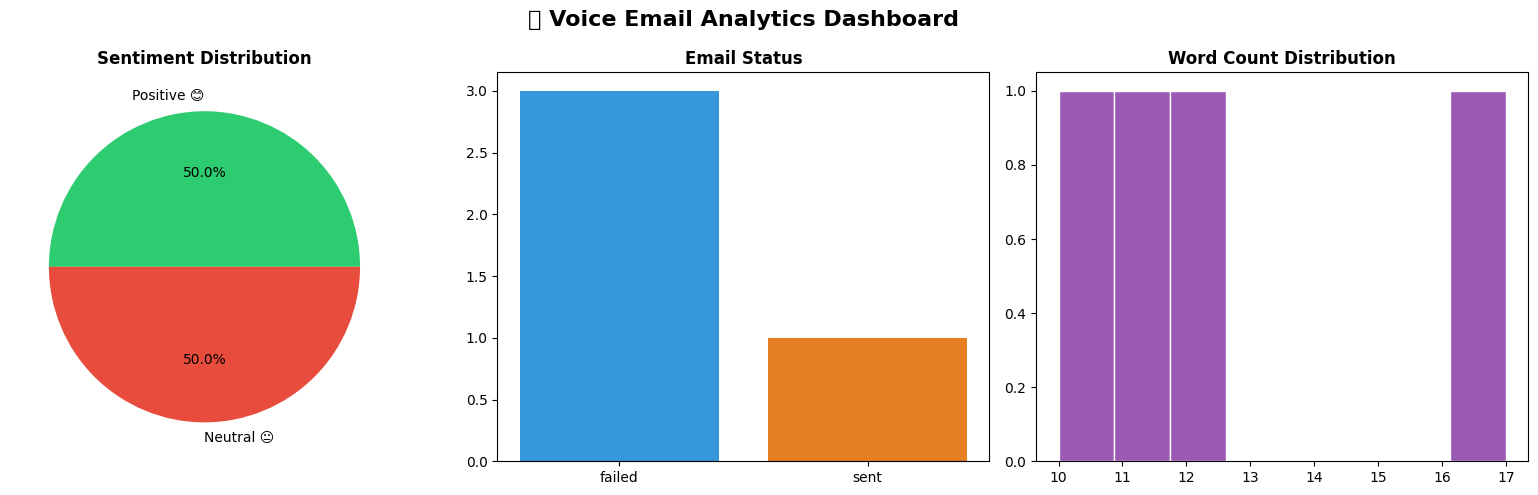


📋 Recent Logs:


,timestamp,recipient,sentiment_label,word_count,status
0,2026-02-28 07:04:16,veeresh21.v@gmail.com,Positive 😊,12,failed
1,2026-02-28 07:09:29,veeresh21.v@gmail.com,Positive 😊,17,failed
2,2026-02-28 07:13:43,veeresh121863@gmail.com,Neutral 😐,10,failed
3,2026-02-28 07:22:32,veeresh21.v@gmail.com,Neutral 😐,11,sent


In [15]:
def show_analytics():
    conn = sqlite3.connect('email_analytics.db')
    df = pd.read_sql_query("SELECT * FROM email_logs", conn)
    conn.close()

    if df.empty:
        print("⚠️ No data yet! Send some emails first.")
        return

    print("="*50)
    print("      📊 EMAIL ANALYTICS DASHBOARD")
    print("="*50)
    print(f"  Total Emails  : {len(df)}")
    print(f"  Sent          : {len(df[df['status']=='sent'])}")
    print(f"  Avg Words     : {round(df['word_count'].mean(), 1)}")
    print(f"  Avg Sentiment : {round(df['sentiment_score'].mean(), 3)}")

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle('📊 Voice Email Analytics Dashboard',
                 fontsize=16, fontweight='bold')

    sentiment_counts = df['sentiment_label'].value_counts()
    axes[0].pie(sentiment_counts.values, labels=sentiment_counts.index,
                autopct='%1.1f%%', colors=['#2ecc71','#e74c3c','#95a5a6'])
    axes[0].set_title('Sentiment Distribution', fontweight='bold')

    status_counts = df['status'].value_counts()
    axes[1].bar(status_counts.index, status_counts.values,
                color=['#3498db','#e67e22','#e74c3c'])
    axes[1].set_title('Email Status', fontweight='bold')

    axes[2].hist(df['word_count'], bins=8,
                 color='#9b59b6', edgecolor='white')
    axes[2].set_title('Word Count Distribution', fontweight='bold')

    plt.tight_layout()
    plt.show()

    print("\n📋 Recent Logs:")
    display(df[['timestamp','recipient','sentiment_label',
                'word_count','status']].tail(5))

show_analytics()

## 📌 Project Summary

| Component | Technology |
|---|---|
| Voice Recognition | SpeechRecognition + Google API |
| Sentiment Analysis | TextBlob NLP |
| Subject Generation | NLP Noun Phrase Extraction |
| Keyword Extraction | NLTK + Counter |
| Data Storage | SQLite Database |
| Visualization | Matplotlib + Pandas |
| Email Sending | yagmail (Gmail SMTP) |

### 🔗 Skills Demonstrated
- End-to-end NLP pipeline
- Data collection, storage and analytics
- Real-world Python application
- Data visualization and dashboarding